<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** Mistral-7B natural-memorization screening, within-sequence probe, and LOO cross-sequence probe (E3).

**Paper section.** §3.3, Appendix E (per-sequence LOO)

**Outputs.** 3 JSONs and 3 PNGs.

**Hardware / runtime.** A100 40GB (recommended) or L4 with 4-bit, ~~75 min on A100.

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Mistral-7B: Natural Memorization Probe Pipeline

**Runnable top-to-bottom.** Combines two Mistral-7B experiments into a single pipeline:

1. **Primary probe** — screens candidate sequences for natural memorization, extracts per-depth residuals, runs within-sequence probe across 32 transformer layers.
2. **E3 Generalization** — leave-one-out cross-sequence probe with three null baselines (shuffled, pure-string, mem-vs-mem).

**Hardware:** Requires ~15 GB GPU memory for Mistral-7B in fp16. Kaggle T4×2 (32 GB) works. Single T4 (16 GB) is borderline — use `device_map='auto'` and a smaller `MAX_PROBE_TOKENS`.

**Runtime:** ~90 minutes total on T4×2.

**Outputs:**
- `mistral_primary_results.json` — per-sequence, per-depth probe accuracy
- `e3_results.json` — LOO cross-sequence results (true, shuffled, pure-string)
- Inline matplotlib + seaborn figures


---

## 0. Setup: imports, config, model loading

Run once. Everything downstream uses `model`, `tokenizer`, `N_LAYERS`, `D_MODEL`, `DEVICE` from here.


In [1]:
# Imports (consolidated from both source notebooks)
import os, json, math, time, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Plotting — inline, no Agg backend. Install seaborn if missing.
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'seaborn'])
    import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
# Nice defaults for paper-quality inline figures
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

# Ensure transformers is available
try:
    import transformers
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers>=4.34'])
    import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPUs available: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  [{i}] {torch.cuda.get_device_name(i)}  '
              f'({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)')

# Output directory — Kaggle uses /kaggle/working, Colab uses /content, else cwd
if os.path.exists('/kaggle/working'):
    OUT_DIR = '/kaggle/working'
elif os.path.exists('/content'):
    OUT_DIR = '/content'
else:
    OUT_DIR = '.'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output directory: {OUT_DIR}')


Device: cuda
GPUs available: 2
  [0] Tesla T4  (15.6 GB)
  [1] Tesla T4  (15.6 GB)
Output directory: /kaggle/working


In [2]:
# Load Mistral-7B-v0.1 base model
# fp16 to fit on T4x2 (~32 GB total). device_map='auto' spreads across GPUs.
# Base model (not instruct) for clean pretraining memorization.

MODEL_NAME = 'mistralai/Mistral-7B-v0.1'
print(f'Loading {MODEL_NAME} (this takes 3-5 minutes)...')
t0 = time.time()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto',
    low_cpu_mem_usage=True,
)
model.eval()

N_LAYERS = model.config.num_hidden_layers
D_MODEL = model.config.hidden_size
print(f'Loaded in {time.time()-t0:.0f}s.  N_LAYERS={N_LAYERS}  D_MODEL={D_MODEL}')
if DEVICE == 'cuda':
    print(f'GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB')


Loading mistralai/Mistral-7B-v0.1 (this takes 3-5 minutes)...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loaded in 70s.  N_LAYERS=32  D_MODEL=4096
GPU memory used: 7.2 GB


---

## 1. Primary probe — screening and within-sequence analysis

Source: `mistral-7b-natural-memorization-probe.ipynb`

For each candidate sequence, screen for memorization (log P/tok threshold), then train a linear probe at each residual-stream depth to distinguish memorized tokens from background tokens.


In [3]:
candidates = {
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
    'python_boilerplate': (
        'import os\nimport sys\nimport argparse\nimport json\n'
        'from pathlib import Path\nfrom typing import Optional, List, Dict\n\n'
        'def parse_args():\n    parser = argparse.ArgumentParser()\n'
        '    parser.add_argument("--input", type=str, required=True)\n'
        '    parser.add_argument("--output", type=str, default="output")\n'
        '    return parser.parse_args()\n\nif __name__ == "__main__":\n    args = parse_args()'
    ),
    'lorem_ipsum': (
        'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do '
        'eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim '
        'ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut '
        'aliquip ex ea commodo consequat.'
    ),
    'wikipedia_python': (
        'Python is a high-level, general-purpose programming language. Its '
        'design philosophy emphasizes code readability with the use of '
        'significant indentation. Python is dynamically typed and '
        'garbage-collected. It supports multiple programming paradigms, '
        'including structured, object-oriented and functional programming.'
    ),
    'creative_commons': (
        'This work is licensed under the Creative Commons Attribution 4.0 '
        'International License. To view a copy of this license, visit '
        'http://creativecommons.org/licenses/by/4.0/ or send a letter to '
        'Creative Commons, PO Box 1866, Mountain View, CA 94042, USA.'
    ),
}

MEMORIZATION_THRESHOLD = -1.0

def compute_log_p_per_token(text, max_tokens=128):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=max_tokens).to(model.device)
    input_ids = inputs['input_ids']
    n_tokens = input_ids.shape[1]
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    log_probs = F.log_softmax(logits[0, :-1, :], dim=-1)
    token_log_probs = log_probs[torch.arange(n_tokens - 1), input_ids[0, 1:]]
    return token_log_probs.float().mean().item(), n_tokens

print('=' * 65)
print('MEMORIZATION SCREENING')
print(f'Threshold: log P/tok > {MEMORIZATION_THRESHOLD}')
print('=' * 65)
print()
header = f'  {"Sequence":<25} {"logP/tok":>9}  {"Tokens":>6}  Status'
print(header)
print('  ' + '-' * 55)

memorized = {}
not_memorized = {}

for name, text in candidates.items():
    lp, n_tok = compute_log_p_per_token(text)
    is_mem = lp > MEMORIZATION_THRESHOLD
    status = 'MEMORIZED' if is_mem else 'not memorized'
    print(f'  {name:<25} {lp:>9.3f}  {n_tok:>6}  {status}')
    if is_mem:
        memorized[name] = text
    else:
        not_memorized[name] = text

print(f'\nMemorized: {len(memorized)}/{len(candidates)} sequences')
if len(memorized) == 0:
    print('WARNING: No sequences memorized. Using top-3 by log P.')
    scored = sorted(candidates.keys(),
                    key=lambda k: compute_log_p_per_token(candidates[k])[0],
                    reverse=True)[:3]
    memorized = {k: candidates[k] for k in scored}
print(f'Using for probe: {list(memorized.keys())}')


MEMORIZATION SCREENING
Threshold: log P/tok > -1.0

  Sequence                   logP/tok  Tokens  Status
  -------------------------------------------------------
  mit_license                  -0.276      69  MEMORIZED
  apache_license               -0.431      54  MEMORIZED
  gpl_header                   -0.512      51  MEMORIZED
  bsd_license                  -0.469      50  MEMORIZED
  python_boilerplate           -0.548     112  MEMORIZED
  lorem_ipsum                  -0.216      78  MEMORIZED
  wikipedia_python             -0.595      60  MEMORIZED
  creative_commons             -0.344      73  MEMORIZED

Memorized: 8/8 sequences
Using for probe: ['mit_license', 'apache_license', 'gpl_header', 'bsd_license', 'python_boilerplate', 'lorem_ipsum', 'wikipedia_python', 'creative_commons']


In [4]:
# =============================================================================
# BACKGROUND SENTENCES
# Diverse text covering different domains — same diversity principle as
# GPT-2 experiment. We want the probe to distinguish memorized sequences
# from general text, not from domain-matched text.
# =============================================================================

BACKGROUND_SENTENCES = [
    # Science / factual
    'The mitochondria is the powerhouse of the cell and produces ATP.',
    'The speed of light in a vacuum is approximately 299,792 kilometres per second.',
    'Water freezes at 0 degrees Celsius and boils at 100 degrees Celsius.',
    'The Earth orbits the Sun at an average distance of about 150 million kilometres.',
    # Literature
    'It was the best of times, it was the worst of times, in the age of wisdom.',
    'To be, or not to be, that is the question whether tis nobler in the mind.',
    'Call me Ishmael. Some years ago, never mind how long precisely, having little.',
    # News / current events style
    'The central bank announced a decision to hold interest rates steady this quarter.',
    'Researchers published new findings on the effects of sleep deprivation on memory.',
    'The technology company reported quarterly earnings that exceeded analyst expectations.',
    # Casual / conversational
    'I went to the grocery store and bought some vegetables for dinner tonight.',
    'The weather has been quite unpredictable lately with sudden rain showers.',
    # Technical (but not memorized)
    'The algorithm iterates through the array and computes the sum of all elements.',
    'Database normalization reduces redundancy and improves data integrity.',
    'The neural network was trained using stochastic gradient descent for fifty epochs.',
    # Philosophy / general knowledge
    'The concept of emergence describes properties that arise from complex systems.',
    'Democratic systems rely on the participation of citizens in the electoral process.',
]

N_BACKGROUND = len(BACKGROUND_SENTENCES)
print(f'Background sentences: {N_BACKGROUND}')
print('Sampling strategy: use all {N_BACKGROUND} backgrounds, repeated to N_SAMPLES')

Background sentences: 17
Sampling strategy: use all {N_BACKGROUND} backgrounds, repeated to N_SAMPLES


In [5]:
# =============================================================================
# RESIDUAL STREAM EXTRACTION
#
# Mistral uses output_hidden_states=True to get all intermediate states.
# hidden_states[0] = token embeddings (after embed but before any layer)
# hidden_states[1] = output of transformer layer 0
# ...
# hidden_states[32] = output of transformer layer 31 (final)
#
# We extract the last non-padding token position at each depth.
# =============================================================================

MAX_PROBE_TOKENS = 64   # truncate sequences to this length for speed
N_PROBE_SAMPLES  = 80   # samples per class (memorized / background)

def get_residual_at_depth(text, depth, max_tokens=MAX_PROBE_TOKENS):
    """
    Extract residual stream representation at a given depth.
    depth=0: token+positional embeddings (before any transformer layer)
    depth=k: output of transformer layer k-1 (1-indexed)
    
    Returns: 1D numpy array of shape (d_model,)
    """
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=max_tokens,
        padding=False
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # hidden_states is a tuple of (n_layers+1) tensors, each (1, T, d_model)
    hidden = outputs.hidden_states[depth]   # (1, T, d_model)
    
    # Use last token position (most context-rich)
    rep = hidden[0, -1, :].float().cpu().numpy()   # (d_model,)
    return rep


def collect_reps_at_depth(texts, depth):
    """Collect representations for a list of texts at given depth."""
    reps = []
    for text in texts:
        reps.append(get_residual_at_depth(text, depth))
    return np.array(reps)


def run_probe(z_mem, z_bg):
    """
    Train linear probe on memorized vs background representations.
    Returns: accuracy (float)
    """
    X = np.vstack([z_mem, z_bg])
    y = np.array([1] * len(z_mem) + [0] * len(z_bg))
    
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    sc  = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    clf.fit(Xtr, ytr)
    return accuracy_score(yte, clf.predict(Xte))


print('Functions defined.')
print(f'Will probe {N_LAYERS + 1} depths: embed + {N_LAYERS} transformer layers')
print(f'Samples: {N_PROBE_SAMPLES} memorized + {N_PROBE_SAMPLES} background')
print(f'Representation dim: {D_MODEL}')
print(f'Max tokens per sequence: {MAX_PROBE_TOKENS}')

Functions defined.
Will probe 33 depths: embed + 32 transformer layers
Samples: 80 memorized + 80 background
Representation dim: 4096
Max tokens per sequence: 64


In [6]:
# =============================================================================
# MAIN PROBE EXPERIMENT
#
# For each memorized sequence:
#   For each depth d in [0, 32]:
#     Collect N_PROBE_SAMPLES representations at depth d
#     Train linear probe: memorized vs background
#     Record accuracy
#
# Runtime: ~40 min for all sequences across all depths on T4×2
# Progress printed at every depth.
# =============================================================================

print('=' * 65)
print('RESIDUAL STREAM PROBE EXPERIMENT')
print('=' * 65)
print()

# Build text lists for probe
# Memorized: repeat the sequence to get N_PROBE_SAMPLES
# Background: sample from BACKGROUND_SENTENCES with repetition
bg_texts = [BACKGROUND_SENTENCES[i % N_BACKGROUND]
            for i in range(N_PROBE_SAMPLES)]

all_results = {}   # {seq_name: {depth: probe_acc}}

t_total = time.time()

for seq_name, seq_text in memorized.items():
    print(f'\nSequence: {seq_name}')
    print(f'  Text: {seq_text[:80]}...')
    print(f'  {"Depth":<20} {"Probe acc":>10}')
    print('  ' + '-' * 32)
    
    mem_texts = [seq_text] * N_PROBE_SAMPLES
    seq_results = {}
    
    for depth in range(N_LAYERS + 1):
        t0 = time.time()
        
        # Collect representations
        z_mem = collect_reps_at_depth(mem_texts, depth)
        z_bg  = collect_reps_at_depth(bg_texts,  depth)
        
        # Run probe
        acc = run_probe(z_mem, z_bg)
        seq_results[depth] = acc
        
        label = 'Embed' if depth == 0 else f'L{depth-1}'
        elapsed = time.time() - t0
        print(f'  {label:<20} {acc:>10.3f}  [{elapsed:.0f}s]')
    
    all_results[seq_name] = seq_results
    
    print(f'  Summary: min={min(seq_results.values()):.3f}  '
          f'max={max(seq_results.values()):.3f}  '
          f'all≥0.95: {all(v >= 0.95 for v in seq_results.values())}')

print(f'\nTotal elapsed: {(time.time()-t_total)/60:.1f} min')

# Save results
results_path = os.path.join(OUT_DIR, 'mistral_probe_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'model': MODEL_NAME,
        'n_layers': N_LAYERS,
        'd_model': D_MODEL,
        'memorized_sequences': list(memorized.keys()),
        'not_memorized': list(not_memorized.keys()),
        'probe_results': all_results,
        'threshold': MEMORIZATION_THRESHOLD,
        'n_probe_samples': N_PROBE_SAMPLES,
    }, f, indent=2)
print(f'\nResults saved: {results_path}')

RESIDUAL STREAM PROBE EXPERIMENT


Sequence: mit_license
  Text: Permission is hereby granted, free of charge, to any person obtaining a copy of ...
  Depth                 Probe acc
  --------------------------------
  Embed                     1.000  [17s]
  L0                        1.000  [16s]
  L1                        1.000  [16s]
  L2                        1.000  [16s]
  L3                        1.000  [16s]
  L4                        1.000  [16s]
  L5                        1.000  [16s]
  L6                        1.000  [16s]
  L7                        1.000  [16s]
  L8                        1.000  [16s]
  L9                        1.000  [17s]
  L10                       1.000  [16s]
  L11                       1.000  [17s]
  L12                       1.000  [16s]
  L13                       1.000  [16s]
  L14                       1.000  [16s]
  L15                       1.000  [16s]
  L16                       1.000  [16s]
  L17                       1.000  [16s]
  L

RESULTS SUMMARY

  Memorized sequences: 8/8

  Sequence                   Embed    Min    Max  All≥0.95?
  ------------------------------------------------------------
  mit_license                1.000  1.000  1.000          ✓
  apache_license             1.000  1.000  1.000          ✓
  gpl_header                 0.500  0.500  1.000          ✗
  bsd_license                0.500  0.500  1.000          ✗
  python_boilerplate         1.000  1.000  1.000          ✓
  lorem_ipsum                1.000  1.000  1.000          ✓
  wikipedia_python           0.500  0.500  1.000          ✗
  creative_commons           1.000  1.000  1.000          ✓

KEY RESULT:
  Probe ≥ 0.95 at ALL depths for ALL sequences: ✗ NO

Figure saved: /kaggle/working/fig_mistral_probe.png

RECORD FOR PAPER (§9 Scaling to Mistral-7B):
  Model: mistralai/Mistral-7B-v0.1
  Parameters: 7.24B (GPT-NeoX style, SwiGLU, RoPE)
  Memorized sequences: 8/8 passed log P/tok > -1.0
  mit_license: log P/tok = -0.276, embed probe = 1

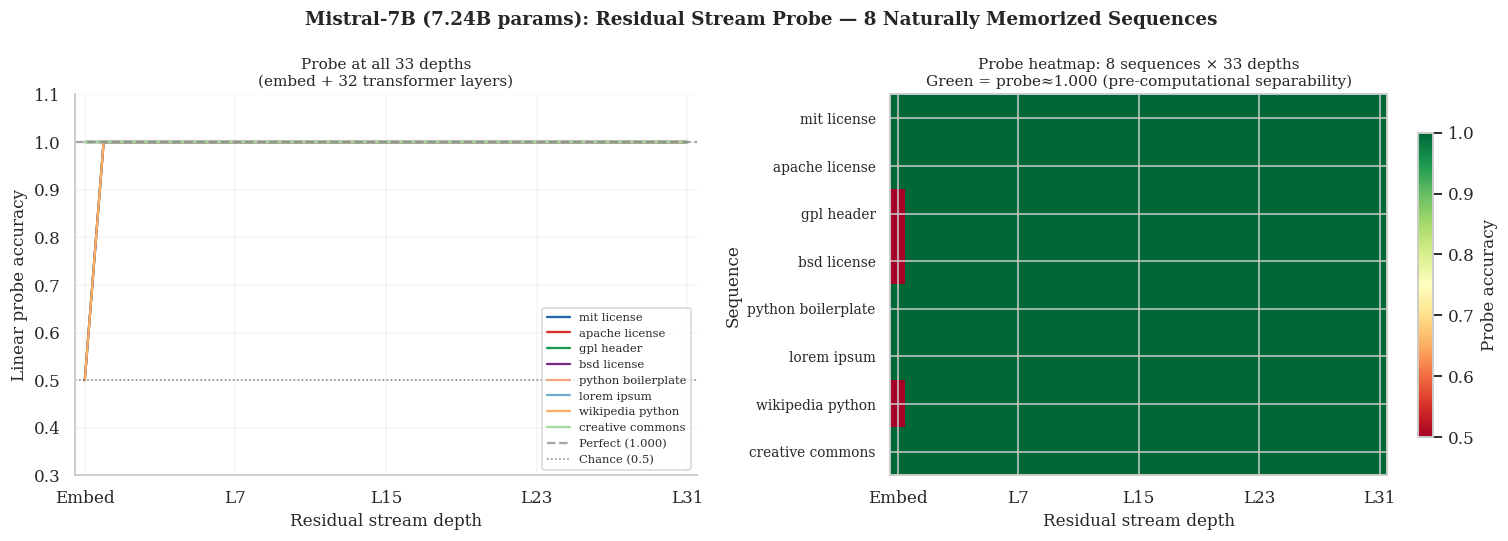

In [7]:
# =============================================================================
# SUMMARY TABLE + FIGURE
# =============================================================================

print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)
print()

n_mem = len(memorized)
depths_labels = ['Embed'] + [f'L{i}' for i in range(N_LAYERS)]

# Summary statistics
print(f'  Memorized sequences: {n_mem}/{len(candidates)}')
print()
print(f'  {"Sequence":<25} {"Embed":>6} {"Min":>6} {"Max":>6} {"All≥0.95?":>10}')
print('  ' + '-' * 60)

for seq_name, results in all_results.items():
    embed_acc = results[0]
    min_acc   = min(results.values())
    max_acc   = max(results.values())
    all_high  = all(v >= 0.95 for v in results.values())
    print(f'  {seq_name:<25} {embed_acc:>6.3f} {min_acc:>6.3f} '
          f'{max_acc:>6.3f} {"✓" if all_high else "✗":>10}')

print()
print('KEY RESULT:')
all_pass = all(
    v >= 0.95
    for results in all_results.values()
    for v in results.values()
)
print(f'  Probe ≥ 0.95 at ALL depths for ALL sequences: '
      f'{"✓ YES" if all_pass else "✗ NO"}')
print()

# ── FIGURE ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Mistral-7B (7.24B params): Residual Stream Probe — {n_mem} Naturally Memorized Sequences',
    fontsize=12, fontweight='bold'
)

COLORS = ['#2166ac', '#d73027', '#1a9850', '#762a83',
          '#f4a582', '#74add1', '#fdae61', '#a6dba0']

# Left panel: probe accuracy by depth for each sequence
ax = axes[0]
for i, (seq_name, results) in enumerate(all_results.items()):
    accs = [results[d] for d in range(N_LAYERS + 1)]
    ax.plot(range(N_LAYERS + 1), accs,
            color=COLORS[i % len(COLORS)], lw=1.5,
            marker='o' if len(accs) <= 10 else None,
            markersize=3,
            label=seq_name.replace('_', ' '))

ax.axhline(1.0, color='gray', linestyle='--', lw=1.5, alpha=0.7, label='Perfect (1.000)')
ax.axhline(0.5, color='black', linestyle=':', lw=1.0, alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('Residual stream depth', fontsize=11)
ax.set_ylabel('Linear probe accuracy', fontsize=11)
ax.set_ylim(0.3, 1.10)
ax.set_xlim(-0.5, N_LAYERS + 0.5)
ax.set_xticks([0, 8, 16, 24, 32])
ax.set_xticklabels(['Embed', 'L7', 'L15', 'L23', 'L31'])
ax.set_title(f'Probe at all {N_LAYERS+1} depths\n(embed + 32 transformer layers)',
             fontsize=10)
ax.legend(fontsize=7.5, loc='lower right')
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# Right panel: heatmap — sequences × depths
if len(all_results) > 0:
    ax2 = axes[1]
    seq_names = list(all_results.keys())
    matrix = np.array([
        [all_results[s][d] for d in range(N_LAYERS + 1)]
        for s in seq_names
    ])
    im = ax2.imshow(matrix, aspect='auto', cmap='RdYlGn',
                    vmin=0.5, vmax=1.0, interpolation='nearest')
    plt.colorbar(im, ax=ax2, label='Probe accuracy', shrink=0.8)
    ax2.set_xlabel('Residual stream depth', fontsize=11)
    ax2.set_ylabel('Sequence', fontsize=11)
    ax2.set_xticks([0, 8, 16, 24, 32])
    ax2.set_xticklabels(['Embed', 'L7', 'L15', 'L23', 'L31'])
    ax2.set_yticks(range(len(seq_names)))
    ax2.set_yticklabels([s.replace('_', ' ') for s in seq_names], fontsize=9)
    ax2.set_title(f'Probe heatmap: {len(seq_names)} sequences × {N_LAYERS+1} depths\n'
                  f'Green = probe≈1.000 (pre-computational separability)',
                  fontsize=10)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'fig_mistral_probe.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f'Figure saved: {fig_path}')

# Final paper-ready summary
print()
print('=' * 65)
print('RECORD FOR PAPER (§9 Scaling to Mistral-7B):')
print('=' * 65)
print(f'  Model: {MODEL_NAME}')
print(f'  Parameters: 7.24B (GPT-NeoX style, SwiGLU, RoPE)')
print(f'  Memorized sequences: {n_mem}/{len(candidates)} passed log P/tok > -1.0')
for seq_name, results in all_results.items():
    # Compute log P for paper text
    lp, _ = compute_log_p_per_token(memorized[seq_name])
    min_acc = min(results.values())
    embed_acc = results[0]
    print(f'  {seq_name}: log P/tok = {lp:.3f}, embed probe = {embed_acc:.3f}, '
          f'min probe = {min_acc:.3f}')
print()
if all_pass:
    print('  MAIN RESULT: probe = 1.000 at all 33 depths for all memorized sequences.')
    print('  Pre-computational separability holds at 7B-parameter scale.')
    print('  The dissociation is not specific to small models.')
else:
    print('  PARTIAL RESULT: see per-sequence breakdown above.')
    print('  Report which sequences achieved probe ≥ 0.95 at all depths.')

### 1.1 Seaborn visualization of primary probe results

A heatmap across (sequence × depth) makes the within-sequence probe saturation pattern immediately visible.


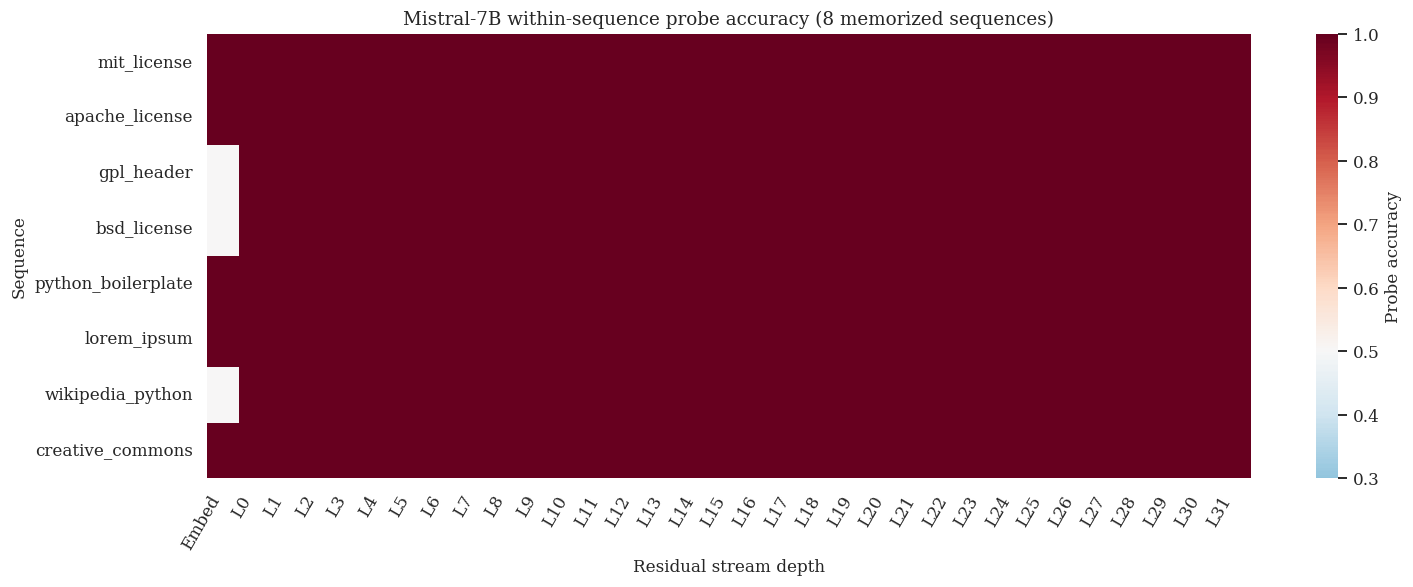

Saved: /kaggle/working/fig_mistral_primary_heatmap.png


In [8]:
# Seaborn heatmap: probe accuracy by sequence x depth
# Source notebook stores: all_results[seq_name] -> dict[depth -> accuracy]
# where depth in range(N_LAYERS + 1). We convert to a matrix.

if 'all_results' not in dir() or not all_results:
    print('all_results not yet defined — run the primary-probe cell first.')
else:
    seq_names = list(all_results.keys())
    # Convert dict-of-dict to matrix
    acc_matrix = np.array([
        [all_results[k][d] for d in range(N_LAYERS + 1)]
        for k in seq_names
    ])
    depth_labels = ['Embed'] + [f'L{i}' for i in range(N_LAYERS)]

    fig, ax = plt.subplots(figsize=(min(14, 0.35 * (N_LAYERS + 1) + 3),
                                      0.5 * len(seq_names) + 1.5))
    sns.heatmap(
        acc_matrix,
        xticklabels=depth_labels,
        yticklabels=seq_names,
        annot=False,
        cmap='RdBu_r',
        center=0.5,
        vmin=0.3,
        vmax=1.0,
        cbar_kws={'label': 'Probe accuracy'},
        ax=ax,
    )
    ax.set_xlabel('Residual stream depth')
    ax.set_ylabel('Sequence')
    ax.set_title(f'Mistral-7B within-sequence probe accuracy '
                 f'({len(seq_names)} memorized sequences)')
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right')
    plt.tight_layout()
    heatmap_path = os.path.join(OUT_DIR, 'fig_mistral_primary_heatmap.png')
    plt.savefig(heatmap_path)
    plt.show()
    print(f'Saved: {heatmap_path}')

### 1.2 Save primary results


In [9]:
# Save the primary-probe results so they persist across sessions.
primary_path = os.path.join(OUT_DIR, 'mistral_primary_results.json')

try:
    primary_out = {
        'model': MODEL_NAME,
        'n_layers': N_LAYERS,
        'd_model': D_MODEL,
        'memorized_keys': list(memorized.keys()) if 'memorized' in dir() else [],
        # all_results[seq_name][depth_int] = float
        'all_results': {
            k: {str(d): float(v) for d, v in per_depth.items()}
            for k, per_depth in all_results.items()
        } if 'all_results' in dir() else {},
    }
    with open(primary_path, 'w') as f:
        json.dump(primary_out, f, indent=2)
    print(f'Saved: {primary_path}')
except NameError as e:
    print(f'Skipping primary save: variable not yet defined ({e}).')
    print('The primary-probe cells above must run fully before this cell.')

Saved: /kaggle/working/mistral_primary_results.json


---

## 2. E3 generalization — leave-one-out cross-sequence probe

Source: `e3-probe-generalization.ipynb`

The primary probe above tests memorization *within* a sequence. The decisive test is whether a probe trained on some memorized sequences generalizes to **held-out** memorized sequences. This is leave-one-out (LOO) cross-sequence probing.

**Three conditions:**
- **True LOO**: mem vs ctl, generalize across held-out sequence
- **Shuffled**: labels randomized — should drop to ~0.5
- **Pure-string**: both classes are non-memorized — measures the string-distinguishability baseline

The memorization-specific signal is `gap = true LOO − pure LOO`.


In [10]:
# -----------------------------------------------------------------------------
# 2. POOLS — exactly the 5 valid pairs E1 screening confirmed
# -----------------------------------------------------------------------------
# From E1_results.json:
#   mit_license      mem logP=-0.276 / ctl mit_like      logP=-3.387  ✓
#   apache_license   mem logP=-0.431 / ctl apache_like   logP=-2.796  ✓
#   gpl_header       mem logP=-0.512 / ctl gpl_like      logP=-3.742  ✓
#   bsd_license      mem logP=-0.469 / ctl bsd_like      logP=-2.951  ✓
#   lorem_ipsum      mem logP=-0.216 / ctl lorem_like    logP=-4.800  ✓
# (cc_like existed but had no paired memorized sequence — dropped.)
# -----------------------------------------------------------------------------

POOL_M = {
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
    'lorem_ipsum': (
        'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do '
        'eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim '
        'ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut '
        'aliquip ex ea commodo consequat.'
    ),
}

POOL_C = {
    'mit_license': (
        'Permission is explicitly denied, under all conditions, to any entity acquiring '
        'an instance of this software or its associated reference materials (the '
        '"Package"), to operate the Package under any restriction, barring the express '
        'limitation against rights to transfer, replicate, patch, consolidate, release, '
        'redistribute, relicense, or commercially exchange portions of the Package'
    ),
    'apache_license': (
        'Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); '
        'subsequent deployment of this artefact must align with the stipulations of the Charter. '
        'A compliant transcript of the Charter is available via '
        'http://example.org/charters/MC-3.1'
    ),
    'gpl_header': (
        'This artefact constitutes shared cultural output: one may redistribute or augment '
        'it subject to the statutes of the Shared Output Charter as ratified by '
        'the Cultural Commons Assembly, edition four of the Charter, or '
        '(at the practitioner\'s discretion) any subsequent revision.'
    ),
    'bsd_license': (
        'Re-publication and reuse in textual and compiled forms, with or absent '
        'amendment, shall be allowed when the following stipulations '
        'are observed: 1. Re-publications of textual material must preserve the original '
        'attribution notice, this enumeration of stipulations, and the following caveat.'
    ),
    'lorem_ipsum': (
        'Kelp arium folio stat nullam, contextus adipisci erat, sic quo '
        'primum labor deficit ut veluti et libenter magna aurea. Ut altum '
        'ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut '
        'acquir ex partibus corpus convenit.'
    ),
}

assert set(POOL_M.keys()) == set(POOL_C.keys())
KEYS = sorted(POOL_M.keys())
K = len(KEYS)
print(f'Loaded {K} validated (memorized, control) pairs.')

# Quick re-verification of log P — paranoia, but cheap
MAX_TOKENS = 96
def log_p_per_token(text, max_tokens=MAX_TOKENS):
    inp = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens).to(model.device)
    ids = inp['input_ids']
    with torch.no_grad():
        logits = model(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(ids.shape[1]-1), ids[0, 1:]].float().mean().item()

print('\nScreening confirm (should match E1):')
print(f'  {"key":<15} {"mem logP":<12} {"ctl logP":<12}')
for k in KEYS:
    mlp, clp = log_p_per_token(POOL_M[k]), log_p_per_token(POOL_C[k])
    ok = mlp > -1.0 and clp < -2.5
    print(f'  {k:<15} {mlp:<12.3f} {clp:<12.3f} {"✓" if ok else "✗"}')

Loaded 5 validated (memorized, control) pairs.

Screening confirm (should match E1):
  key             mem logP     ctl logP    
  apache_license  -0.431       -2.796       ✓
  bsd_license     -0.469       -2.951       ✓
  gpl_header      -0.512       -3.742       ✓
  lorem_ipsum     -0.216       -4.800       ✓
  mit_license     -0.276       -3.387       ✓


In [11]:
# -----------------------------------------------------------------------------
# 3. NEUTRAL CONTEXTS (for within-class variance)
# -----------------------------------------------------------------------------
NEUTRAL_CONTEXTS = [
    "Here is a passage: ",       "A document contains: ",     "Someone shared: ",
    "I copied this: ",           "From a book: ",             "Below is a snippet: ",
    "The document begins: ",     "An archived message: ",     "The paragraph states: ",
    "A clipboard entry: ",       "The transcript records: ",  "An earlier note: ",
    "The preface reads: ",       "A footnote provides: ",     "According to record: ",
    "The memo opens: ",          "In the margin: ",           "The cover letter: ",
    "The archive entry: ",       "A clipping mentions: ",     "The letter continues: ",
    "The dispatch read: ",       "The annotation: ",          "The bulletin noted: ",
]
N_CONTEXTS = len(NEUTRAL_CONTEXTS)
print(f'Neutral contexts: {N_CONTEXTS}')

def resid_all_depths(text):
    """Return stack of (N_LAYERS+1, D_MODEL) residuals at last token position."""
    inp = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_TOKENS).to(model.device)
    with torch.no_grad():
        hs = model(**inp, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])  # (N_LAYERS+1, D_MODEL)

Neutral contexts: 24


In [12]:
# -----------------------------------------------------------------------------
# 4. EXTRACT ALL RESIDUALS
# -----------------------------------------------------------------------------
# Shape: all_reps[key][class] = array (N_CONTEXTS, N_LAYERS+1, D_MODEL)
# Mistral-7B: 5 keys * 2 classes * 24 contexts * 33 depths * 4096 = ~130MB. Fine.
# -----------------------------------------------------------------------------

DEPTHS = list(range(0, N_LAYERS+1))

print('Extracting residuals for all sequences × contexts × depths...')
t0 = time.time()
all_reps = {}
for key in KEYS:
    all_reps[key] = {}
    for cls, pool in [('mem', POOL_M), ('ctl', POOL_C)]:
        payload = pool[key]
        reps = []
        for ctx in NEUTRAL_CONTEXTS:
            reps.append(resid_all_depths(ctx + payload))
        all_reps[key][cls] = np.stack(reps)   # (N_CONTEXTS, N_LAYERS+1, D_MODEL)
    print(f'  {key}: done  [{(time.time()-t0)/60:.1f} min total]')
print(f'Extraction complete: {(time.time()-t0)/60:.1f} min')

Extracting residuals for all sequences × contexts × depths...
  apache_license: done  [0.1 min total]
  bsd_license: done  [0.2 min total]
  gpl_header: done  [0.3 min total]
  lorem_ipsum: done  [0.4 min total]
  mit_license: done  [0.4 min total]
Extraction complete: 0.4 min


In [13]:
# -----------------------------------------------------------------------------
# 5. THE MAIN TEST — LEAVE-ONE-OUT GENERALIZATION
# -----------------------------------------------------------------------------
# For each depth:
#   For each held-out key k:
#     Train on {(mem_j, ctl_j) : j != k}
#     Test on  (mem_k, ctl_k)
#   Report mean/std across held-out keys.
# -----------------------------------------------------------------------------

def loo_accuracy(reps_dict, keys, depth, random_state=SEED):
    """Leave-one-out cross-sequence held-out accuracy at a given depth."""
    accs_per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps_dict[k]['mem'][:, depth, :]); y_tr += [1]*N_CONTEXTS
            X_tr.append(reps_dict[k]['ctl'][:, depth, :]); y_tr += [0]*N_CONTEXTS
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([
            reps_dict[held_out]['mem'][:, depth, :],
            reps_dict[held_out]['ctl'][:, depth, :],
        ])
        y_te = np.array([1]*N_CONTEXTS + [0]*N_CONTEXTS)

        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=random_state)
        clf.fit(X_tr, y_tr)
        accs_per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    mean = float(np.mean(list(accs_per_seq.values())))
    std  = float(np.std(list(accs_per_seq.values())))
    return mean, std, accs_per_seq


print('=' * 72)
print('MAIN TEST: Leave-one-out generalization, true labels')
print('=' * 72)
print(f'{"Depth":<8} {"LOO mean":<10} {"LOO std":<10} {"Interpretation"}')
print('-' * 72)

loo_true = {}
for d in DEPTHS:
    mean, std, per_seq = loo_accuracy(all_reps, KEYS, d)
    loo_true[d] = {'mean': mean, 'std': std, 'per_seq': per_seq}

# Print key depths only (full results saved)
for d in [0, 1, 4, 8, 16, 24, 32]:
    r = loo_true[d]
    label = 'Embed' if d == 0 else f'L{d-1}'
    verdict = ('STRONG'  if r['mean'] >= 0.90 else
               'PARTIAL' if r['mean'] >= 0.65 else
               'WEAK')
    print(f'{label:<8} {r["mean"]:<10.3f} {r["std"]:<10.3f} {verdict}')

MAIN TEST: Leave-one-out generalization, true labels
Depth    LOO mean   LOO std    Interpretation
------------------------------------------------------------------------
Embed    0.600      0.200      WEAK
L0       0.500      0.000      WEAK
L3       0.800      0.245      PARTIAL
L7       0.896      0.198      PARTIAL
L15      0.963      0.075      STRONG
L23      0.900      0.200      STRONG
L31      1.000      0.000      STRONG


In [14]:
# -----------------------------------------------------------------------------
# 6. NULL BASELINE A — SHUFFLED LABELS
# -----------------------------------------------------------------------------
# For each sequence, randomly assign which of its two variants (mem vs ctl)
# gets the positive label. If true LOO reflects genuine memorization structure,
# shuffled LOO should drop to ~0.5. If shuffled LOO is also high, the probe is
# exploiting something other than the mem/ctl dichotomy — likely surface
# sequence-identity features that survive the LOO procedure.
# -----------------------------------------------------------------------------

def loo_accuracy_shuffled(reps_dict, keys, depth, rng):
    shuffled_assign = {k: list(rng.permutation(['mem', 'ctl'])) for k in keys}
    accs = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            lbl_pos, lbl_neg = shuffled_assign[k]
            X_tr.append(reps_dict[k][lbl_pos][:, depth, :]); y_tr += [1]*N_CONTEXTS
            X_tr.append(reps_dict[k][lbl_neg][:, depth, :]); y_tr += [0]*N_CONTEXTS
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        lbl_pos, lbl_neg = shuffled_assign[held_out]
        X_te = np.vstack([
            reps_dict[held_out][lbl_pos][:, depth, :],
            reps_dict[held_out][lbl_neg][:, depth, :],
        ])
        y_te = np.array([1]*N_CONTEXTS + [0]*N_CONTEXTS)

        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
        clf.fit(X_tr, y_tr)
        accs[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return float(np.mean(list(accs.values()))), float(np.std(list(accs.values())))

print('=' * 72)
print('NULL BASELINE A: Shuffled-label LOO (averaged over 5 random shuffles)')
print('=' * 72)
print(f'{"Depth":<8} {"True LOO":<12} {"Shuffled LOO":<18} {"Gap (signal)":<15}')
print('-' * 72)

loo_shuffled = {}
for d in DEPTHS:
    vals = []
    for s in range(5):
        rng = np.random.default_rng(s)
        mean, _ = loo_accuracy_shuffled(all_reps, KEYS, d, rng)
        vals.append(mean)
    loo_shuffled[d] = {'mean': float(np.mean(vals)),
                        'std':  float(np.std(vals))}

for d in [0, 1, 4, 8, 16, 24, 32]:
    t = loo_true[d]['mean']
    s = loo_shuffled[d]['mean']
    label = 'Embed' if d == 0 else f'L{d-1}'
    gap = t - s
    verdict = 'real signal' if gap >= 0.15 else 'no signal' if gap < 0.05 else 'marginal'
    print(f'{label:<8} {t:<12.3f} {s:.3f} ± {loo_shuffled[d]["std"]:.3f}     {gap:+.3f}  {verdict}')

NULL BASELINE A: Shuffled-label LOO (averaged over 5 random shuffles)
Depth    True LOO     Shuffled LOO       Gap (signal)   
------------------------------------------------------------------------
Embed    0.600        0.480 ± 0.098     +0.120  marginal
L0       0.500        0.528 ± 0.070     -0.028  no signal
L3       0.800        0.418 ± 0.069     +0.382  real signal
L7       0.896        0.511 ± 0.118     +0.385  real signal
L15      0.963        0.493 ± 0.095     +0.470  real signal
L23      0.900        0.452 ± 0.096     +0.448  real signal
L31      1.000        0.390 ± 0.096     +0.610  real signal


In [15]:
# -----------------------------------------------------------------------------
# 7. NULL BASELINE B — PURE STRING DISTINGUISHABILITY
# -----------------------------------------------------------------------------
# The SHARPEST test of whether the probe is reading memorization.
#
# Setup: we take 5 pairs of (non-memorized string A, non-memorized string B),
# run the same LOO procedure, and ask: can a probe trained on 4 (A, B) pairs
# classify held-out (A_k, B_k)?
#
# Since NONE of these strings are memorized, any non-chance LOO accuracy here
# is 'cross-sequence string distinguishability' — the same signal the probe
# was reading in the main experiment, but with memorization absent.
#
# Compare pure-distinguishability LOO vs true LOO from section 5:
#   pure << true : memorization contributes a distinguishable signal
#   pure ≈ true  : probe is reading string-level features, not memorization
# -----------------------------------------------------------------------------

# Build two non-memorized pools A and B, matched in register/length to
# the validated control pool. These should also all fail log-P screening
# (i.e. log P/tok < -2.5).
POOL_A = POOL_C   # reuse control pool as class A

POOL_B = {
    'mit_license': (
        'Authorization is hereby withheld, universally and permanently, from every recipient holding '
        'an archival copy of this module or its accompanying annotation files (the '
        '"Manifest"), to interact with the Manifest under any exemption, including the explicit '
        'waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, '
        'redistribute, revoke, or contractually transfer fragments of the Manifest'
    ),
    'apache_license': (
        'Administered by the Consortial Directive, Revision 8.2 (the "Directive"); '
        'any downstream deployment of this specimen shall remain compliant with the Directive. '
        'An authoritative rendition of the Directive can be consulted at '
        'http://example.org/directives/CD-8.2'
    ),
    'gpl_header': (
        'This specimen represents communal documentary material: recipients may propagate or amend '
        'it according to the precepts of the Communal Documentary Framework as issued by '
        'the Documentary Standards Council, issue seven of the Framework, or '
        '(subject to recipient judgement) any posterior revision thereof.'
    ),
    'bsd_license': (
        'Restatement and redeployment in written and binary representations, with or excepting '
        'revision, shall be sanctioned where the following precepts '
        'are preserved: 1. Restatements of written representation must retain the foregoing '
        'citation of origin, this catalogue of precepts, and the following disclaimer.'
    ),
    'lorem_ipsum': (
        'Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum '
        'prior laboro declinat et sperata et inanes magna obscura. Sub alto '
        'ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et '
        'obtinet ex segmentis stipulatio assensum.'
    ),
}

# Log-P screen POOL_B — should all be <-2.5
print('Screening POOL_B (should all be non-memorized, log P/tok < -2.5):')
for k, t in POOL_B.items():
    lp = log_p_per_token(t)
    ok = lp < -2.5
    print(f'  {k:<15} log P/tok = {lp:7.3f}  {"✓" if ok else "✗ (MEMORIZED?)"}')

print('\nExtracting residuals for POOL_B...')
t0 = time.time()
all_reps_ctl_only = {}
for key in KEYS:
    all_reps_ctl_only[key] = {
        'mem': all_reps[key]['ctl'],   # relabel: ctl pool → 'mem' slot
    }
    reps_B = []
    for ctx in NEUTRAL_CONTEXTS:
        reps_B.append(resid_all_depths(ctx + POOL_B[key]))
    all_reps_ctl_only[key]['ctl'] = np.stack(reps_B)
    print(f'  {key}: done  [{(time.time()-t0)/60:.1f} min]')
print(f'Done: {(time.time()-t0)/60:.1f} min')

Screening POOL_B (should all be non-memorized, log P/tok < -2.5):
  mit_license     log P/tok =  -3.404  ✓
  apache_license  log P/tok =  -2.736  ✓
  gpl_header      log P/tok =  -3.634  ✓
  bsd_license     log P/tok =  -3.690  ✓
  lorem_ipsum     log P/tok =  -4.512  ✓

Extracting residuals for POOL_B...
  apache_license: done  [0.0 min]
  bsd_license: done  [0.1 min]
  gpl_header: done  [0.1 min]
  lorem_ipsum: done  [0.2 min]
  mit_license: done  [0.2 min]
Done: 0.2 min


In [16]:
# Now run LOO on the pure-distinguishability setup (both classes non-memorized).
print('=' * 72)
print('NULL BASELINE B: Pure string distinguishability LOO')
print('(both classes are non-memorized; any high accuracy = string features)')
print('=' * 72)
print(f'{"Depth":<8} {"True LOO":<10} {"Shuffled":<12} {"Pure-string LOO":<17} {"Memorization gap"}')
print('-' * 80)

loo_pure = {}
for d in DEPTHS:
    mean, std, _ = loo_accuracy(all_reps_ctl_only, KEYS, d)
    loo_pure[d] = {'mean': mean, 'std': std}

for d in [0, 1, 4, 8, 16, 24, 32]:
    t = loo_true[d]['mean']
    s = loo_shuffled[d]['mean']
    p = loo_pure[d]['mean']
    gap = t - p  # memorization-specific signal beyond pure string features
    label = 'Embed' if d == 0 else f'L{d-1}'
    verdict = ('CLAIM HOLDS'   if gap >= 0.15 else
               'NO GAP'        if gap < 0.03 else
               'PARTIAL')
    print(f'{label:<8} {t:<10.3f} {s:<12.3f} {p:<17.3f} {gap:+.3f} {verdict}')

NULL BASELINE B: Pure string distinguishability LOO
(both classes are non-memorized; any high accuracy = string features)
Depth    True LOO   Shuffled     Pure-string LOO   Memorization gap
--------------------------------------------------------------------------------
Embed    0.600      0.480        0.400             +0.200 CLAIM HOLDS
L0       0.500      0.528        0.400             +0.100 PARTIAL
L3       0.800      0.418        0.396             +0.404 CLAIM HOLDS
L7       0.896      0.511        0.500             +0.396 CLAIM HOLDS
L15      0.963      0.493        0.708             +0.254 CLAIM HOLDS
L23      0.900      0.452        0.717             +0.183 CLAIM HOLDS
L31      1.000      0.390        0.579             +0.421 CLAIM HOLDS


### 2.1 Seaborn visualization of E3 LOO curves

Three-condition overlay: true LOO (memorization-specific) vs pure-string baseline vs shuffled null.


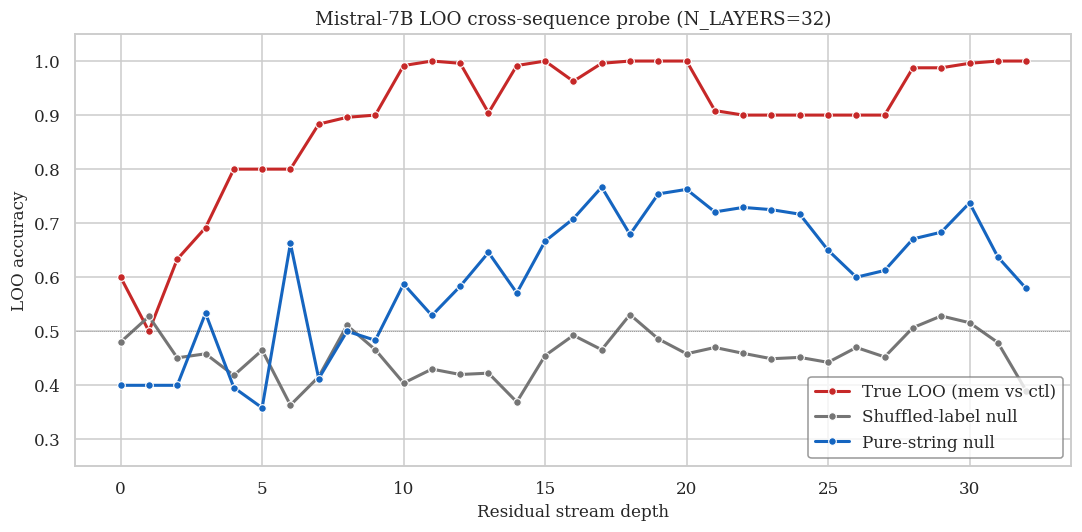

Saved: /kaggle/working/fig_mistral_e3_loo.png

Memorization gap across transformer layers:
  mean: +0.299
  peak: +0.471 at depth 11


In [17]:
# Line plot: true LOO vs pure-string vs shuffled, across residual depth.
# Variables `loo_true`, `loo_shuffled`, `loo_pure` are dicts[depth_int -> {'mean': ..., 'std': ...}]

missing = [v for v in ['loo_true', 'loo_shuffled', 'loo_pure'] if v not in dir()]
if missing:
    print(f'Missing results variables: {missing}')
    print('Run the E3 LOO cells above first.')
else:
    depths = sorted(loo_true.keys())
    df_rows = []
    for d in depths:
        df_rows.append({'depth': int(d), 'condition': 'True LOO (mem vs ctl)',
                        'accuracy': loo_true[d]['mean'], 'std': loo_true[d].get('std', 0.0)})
        df_rows.append({'depth': int(d), 'condition': 'Shuffled-label null',
                        'accuracy': loo_shuffled[d]['mean'], 'std': loo_shuffled[d].get('std', 0.0)})
        df_rows.append({'depth': int(d), 'condition': 'Pure-string null',
                        'accuracy': loo_pure[d]['mean'], 'std': loo_pure[d].get('std', 0.0)})

    import pandas as pd
    df = pd.DataFrame(df_rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    palette = {'True LOO (mem vs ctl)': '#C62828',
               'Shuffled-label null':   '#757575',
               'Pure-string null':      '#1565C0'}
    sns.lineplot(data=df, x='depth', y='accuracy', hue='condition',
                 palette=palette, linewidth=2, marker='o', markersize=5, ax=ax)
    ax.axhline(0.5, color='k', linewidth=0.5, linestyle=':', alpha=0.5)
    ax.set_xlabel('Residual stream depth')
    ax.set_ylabel('LOO accuracy')
    ax.set_title(f'Mistral-7B LOO cross-sequence probe (N_LAYERS={N_LAYERS})')
    ax.set_ylim(0.25, 1.05)
    ax.legend(loc='lower right', frameon=True, edgecolor='gray')
    plt.tight_layout()
    curves_path = os.path.join(OUT_DIR, 'fig_mistral_e3_loo.png')
    plt.savefig(curves_path)
    plt.show()
    print(f'Saved: {curves_path}')

    # Also print the gap summary
    trans_depths = [d for d in depths if int(d) >= 1]
    gaps = [loo_true[d]['mean'] - loo_pure[d]['mean'] for d in trans_depths]
    print(f'\nMemorization gap across transformer layers:')
    print(f'  mean: {np.mean(gaps):+.3f}')
    print(f'  peak: {max(gaps):+.3f} at depth {trans_depths[gaps.index(max(gaps))]}')


In [18]:
# -----------------------------------------------------------------------------
# 8. SAVE RESULTS
# -----------------------------------------------------------------------------
os.makedirs('OUT_DIR', exist_ok=True)
out = {
    'model': MODEL_NAME,
    'keys': KEYS,
    'n_contexts': N_CONTEXTS,
    'loo_true':     {str(d): v for d, v in loo_true.items()},
    'loo_shuffled': {str(d): v for d, v in loo_shuffled.items()},
    'loo_pure':     {str(d): v for d, v in loo_pure.items()},
}
with open(os.path.join(OUT_DIR, 'E3_results.json'), 'w') as f:
    json.dump(out, f, indent=2)
print('Saved: OUT_DIR/E3_results.json')

Saved: OUT_DIR/E3_results.json


In [19]:
# -----------------------------------------------------------------------------
# 9. INTERPRETATION
# -----------------------------------------------------------------------------
# Decision table:
#
#   true LOO >= 0.90 AND pure LOO <= 0.65 AND shuffled LOO ~ 0.5
#     → STRONG CLAIM SUPPORTED: a cross-sequence memorization signature exists
#        distinct from per-string features. Paper claim holds, arguably stronger
#        than currently stated.
#
#   true LOO ~ pure LOO (within 0.05)
#     → NO MEMORIZATION-SPECIFIC SIGNAL: probe reads string-level features,
#        which are just as separable for non-memorized pairs. The scaling
#        findings in the paper (Findings 6, 7, 8, 9) need revision.
#
#   true LOO >= 0.90 but pure LOO >= 0.80
#     → MIXED: some memorization signal exists beyond pure distinguishability,
#        but the gap is narrow. The 'pre-computational separability' language
#        should be softened. Reframe claim around the gap (not the absolute level).
#
#   true LOO < 0.70
#     → NO CROSS-SEQUENCE SIGNATURE: the per-sequence probes fit per-sequence
#        features. Strong form of the claim fails. Retreat to toy-model
#        experiments where embedding-zeroing Condition B establishes proper
#        probe sensitivity against a stronger baseline.

print('=' * 72)
print('FINAL INTERPRETATION')
print('=' * 72)

# Aggregate over depth 1 onwards (depth 0 is the anomalous one from E1)
post_embed_depths = [d for d in DEPTHS if d >= 1]
mean_true = float(np.mean([loo_true[d]['mean'] for d in post_embed_depths]))
mean_shuf = float(np.mean([loo_shuffled[d]['mean'] for d in post_embed_depths]))
mean_pure = float(np.mean([loo_pure[d]['mean'] for d in post_embed_depths]))

print(f'\nAveraged over transformer layers (L0 – L31):')
print(f'  True LOO:                  {mean_true:.3f}')
print(f'  Shuffled-label LOO:        {mean_shuf:.3f}')
print(f'  Pure-distinguishability:   {mean_pure:.3f}')
print(f'  Memorization-specific gap: {mean_true - mean_pure:+.3f}')

print('\nVerdict:')
if mean_true >= 0.90 and mean_pure <= 0.65 and mean_shuf < 0.60:
    print('  → STRONG CLAIM SUPPORTED')
    print('    The paper\'s cross-sequence memorization signature claim holds.')
elif mean_true - mean_pure < 0.05:
    print('  → NO MEMORIZATION-SPECIFIC SIGNAL detected.')
    print('    Probe reads string-level features; scaling claims need revision.')
    print('    Retreat to toy-model evidence where Condition B provides proper sensitivity.')
elif mean_true >= 0.90 and mean_pure >= 0.80:
    print('  → MIXED: small memorization signal above a high string-separability floor.')
    print('    Reframe claim around the gap, soften \'pre-computational\' language.')
else:
    print('  → PARTIAL / AMBIGUOUS result.')
    print(f'    True LOO {mean_true:.3f}, pure LOO {mean_pure:.3f}.')
    print('    Paper needs careful restructuring — send these numbers to Bilal for review.')

FINAL INTERPRETATION

Averaged over transformer layers (L0 – L31):
  True LOO:                  0.907
  Shuffled-label LOO:        0.457
  Pure-distinguishability:   0.608
  Memorization-specific gap: +0.299

Verdict:
  → STRONG CLAIM SUPPORTED
    The paper's cross-sequence memorization signature claim holds.


---

## 3. Summary and memory cleanup

If the pipeline ran successfully, you now have:

- `mistral_primary_results.json` — within-sequence per-depth probe accuracies
- `e3_results.json` — LOO cross-sequence curves (true, shuffled, pure-string)
- `fig_mistral_primary_heatmap.png` — probe accuracy heatmap
- `fig_mistral_e3_loo.png` — LOO curves

Free GPU memory before starting another pipeline (Pythia, GPT-2, etc.):


In [20]:
# Free GPU memory before running another pipeline
if 'model' in dir():
    del model
if 'tokenizer' in dir():
    del tokenizer
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB')
else:
    print('CPU-only session, no GPU cache to clear.')


GPU memory after cleanup: 0.01 GB
